In [3]:
import torch

ckpt = torch.load(checkpoint_path, map_location="cpu")
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

def dump_dict(d, prefix=""):
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            print(f"{name}/")
            dump_dict(v, prefix=name + ".")
        elif torch.is_tensor(v):
            print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
        else:
            print(f"{name:60s} | type={type(v)}")

dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

NameError: name 'checkpoint_path' is not defined

Loading model from /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth ...
Masked (Softplus * mask): sparsity=88.11% (non-zero 487/4096)


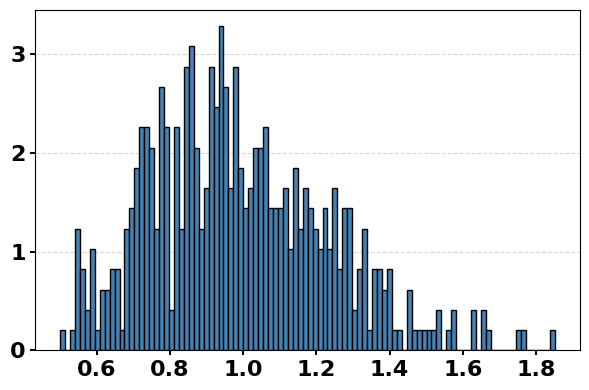

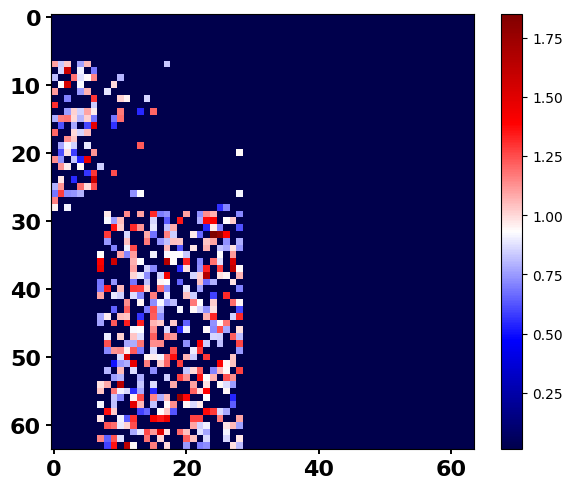

Quantized w Non-zero PTQ: sparsity=88.11% (non-zero 487/4096)


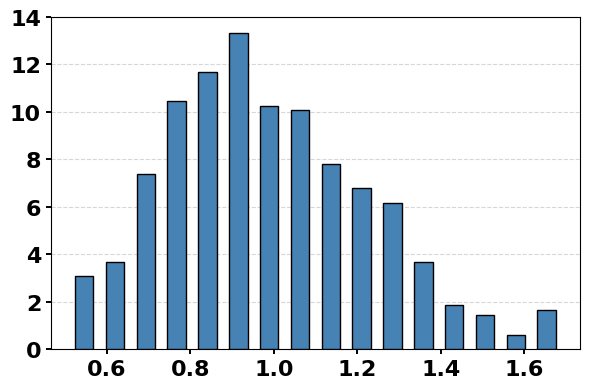

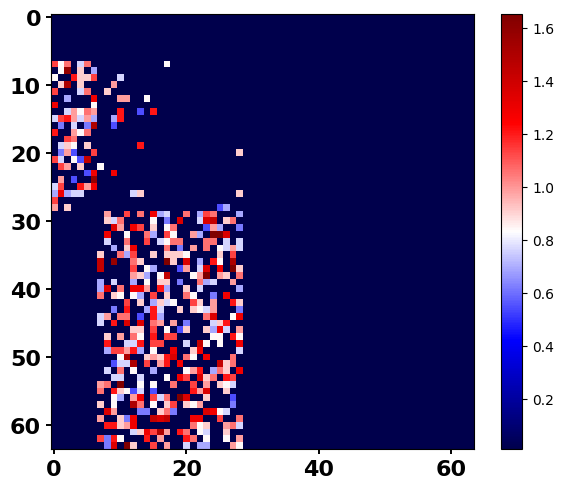

Quantized w_rev Non-zero PTQ: sparsity=88.18% (non-zero 484/4096)


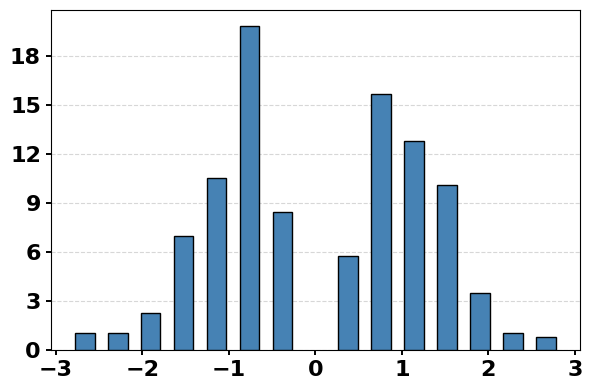

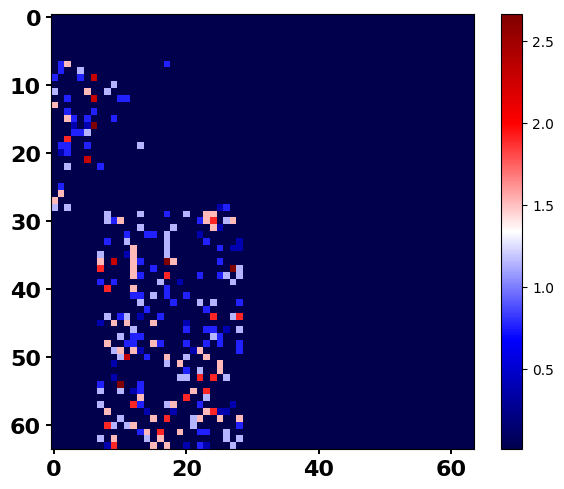

In [28]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F

# ------------------------------------------------------------------
# ユーティリティ関数
# ------------------------------------------------------------------
def flatten_dict(d, prefix=""):
    flat = {}
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_dict(v, prefix=name + "."))
        else:
            flat[name] = v
    return flat

def find_key_endswith(flat_dict, suffix):
    for k in flat_dict.keys():
        if k.endswith(suffix):
            return k
    return None

# ------------------------------------------------------------------
# 非ゼロ PTQ
# ------------------------------------------------------------------
def ptq_weight_nonzero(self, params: torch.Tensor, n_bits: int = 8, percentile: float = 0.99, symmetric: bool = True):
    """
    Sparse weights PTQ:
    - Only non-zero elements are quantized
    - Zero is preserved
    """
    assert n_bits >= 2
    if percentile > 1.0:
        percentile /= 100.0

    with torch.no_grad():
        x = params.to(torch.float32)
        nz_mask = x != 0
        nz = x[nz_mask]
        if nz.numel() == 0:
            return params

        if symmetric:
            q = torch.quantile(nz.abs(), percentile)
            nz_clipped = nz.clamp(min=-q, max=q)
        else:
            low = torch.quantile(nz, 1.0 - percentile)
            high = torch.quantile(nz, percentile)
            nz_clipped = nz.clamp(min=low, max=high)

        if symmetric:
            qmax = 2 ** (n_bits - 1) - 1
            abs_max = nz_clipped.abs().max()
            if abs_max < 1e-12:
                return params
            scale = abs_max / qmax
            nz_q = torch.round(nz_clipped / scale).clamp(-qmax, qmax) * scale
        else:
            qmax = 2 ** n_bits - 1
            min_val = nz_clipped.min()
            max_val = nz_clipped.max()
            if max_val - min_val < 1e-12:
                return params
            scale = (max_val - min_val) / qmax
            nz_q = torch.round((nz_clipped - min_val) / scale).clamp(0, qmax) * scale + min_val

        out = x.clone()
        out[nz_mask] = nz_q
        params.copy_(out.to(params.dtype))

    return params

# ------------------------------------------------------------------
# プロット関数 (修正版)
# ------------------------------------------------------------------
def plot_separated_stages(checkpoint_path: str):
    print(f"Loading model from {checkpoint_path} ...")
    state = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]

    flat = flatten_dict(state)

    w_key = find_key_endswith(flat, "rnn_cell.w")
    mask_key = find_key_endswith(flat, "rnn_cell.sparsity_mask")
    erev_key = find_key_endswith(flat, "rnn_cell.erev")

    if not (w_key and mask_key and erev_key):
        print("Error: 必要なパラメータが見つかりません。")
        return

    w_raw = flat[w_key]
    mask = flat[mask_key]
    erev = flat[erev_key]

    # ------------------------------------------------------------------
    # データ変換パイプライン
    # ※ 必要に応じてコメントアウトを外してRawデータも確認可能
    # ------------------------------------------------------------------
    stages = [
        # ("Raw Weights (w)", w_raw),
        # ("Softplus (Positive)", F.softplus(w_raw)),
        ("Masked (Softplus * mask)", F.softplus(w_raw) * mask),
        ("Quantized w Non-zero PTQ", ptq_weight_nonzero(None, F.softplus(w_raw) * mask, n_bits=4, symmetric=False)),
        ("Quantized w_rev Non-zero PTQ", ptq_weight_nonzero(None, F.softplus(w_raw) * mask * erev, n_bits=4, symmetric=True)),
    ]

    # ------------------------------------------------------------------
    # 描画設定
    # ------------------------------------------------------------------
    tick_size = 16
    tick_width = 1.4
    tick_weight = "bold"

    for name, data in stages:
        flat_data = data.detach().cpu().numpy().flatten()
        nz_data = flat_data[flat_data != 0] # 非ゼロ要素のみ抽出
        mat_data = data.detach().cpu().numpy()
        
        zero_ratio = 1.0 - (len(nz_data) / len(flat_data))
        print(f"{name}: sparsity={zero_ratio*100:.2f}% (non-zero {len(nz_data)}/{len(flat_data)})")

        # --- ヒストグラム描画 (自動分岐) ---
        if name != "Raw Weights (w)" and len(nz_data) > 0:
            plt.figure(figsize=(6, 4))
            
            # ユニーク値を取得して分岐判定
            vals = np.unique(nz_data)
            
            # 【分岐A】 ユニーク値が多い = 連続値 (Raw Weightsなど)
            if len(vals) > 50:
                # count / total (Fraction) を計算するための重み
                weights = np.ones_like(nz_data) / len(nz_data) * 100 # 全体に対する割合
                
                # bins=100 で滑らかに表示
                plt.hist(nz_data, bins=100, weights=weights, 
                         color="steelblue", edgecolor="black", zorder=3) # log=Trueで見やすく

            # 【分岐B】 ユニーク値が少ない = 離散値 (量子化済み)
            else:
                vals, counts = np.unique(nz_data, return_counts=True)
                weights = counts / counts.sum() * 100 # 全体に対する割合
                
                if len(vals) > 1:
                    step = np.min(np.diff(np.sort(vals)))
                    width = step * 0.6
                else:
                    width = 0.2
                
                plt.bar(vals, weights, width=width, color="steelblue", edgecolor="black", zorder=3)

            plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0) # グリッド追加
            
            ax = plt.gca()
            ax.tick_params(axis="both", labelsize=tick_size, width=tick_width)
            ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                lbl.set_fontweight(tick_weight)
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"{name} has no non-zero elements. Skip histogram.")

        # --- ヒートマップ描画 (変更なし) ---
        plt.figure(figsize=(6, 5))
        abs_max = np.abs(mat_data).max()
        if abs_max == 0: abs_max = 1.0
        plt.imshow(mat_data, cmap="seismic", vmin=0.01, vmax=abs_max, aspect="auto", interpolation="nearest")
        plt.colorbar()
        
        ax = plt.gca()
        ax.tick_params(axis="both", labelsize=tick_size, width=tick_width)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight(tick_weight)
        
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------
# 実行
# ------------------------------------------------------------------
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth"
plot_separated_stages(path)

Total keys found: 130


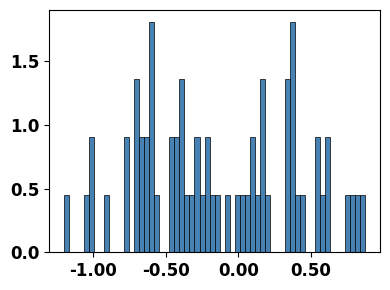

Sparsity mask or weights not found.
Total keys found: 130


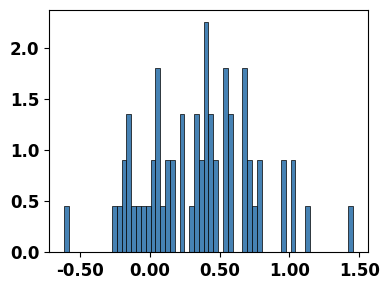

Sparsity mask or weights not found.
Total keys found: 130


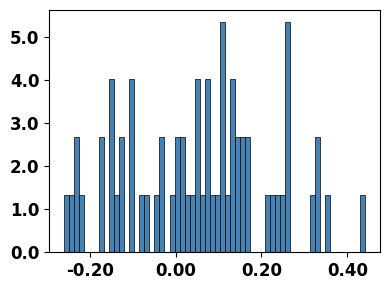

Sparsity mask or weights not found.


In [ ]:
# Digital RRAM
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.cm"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.gleak"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.vleak"])

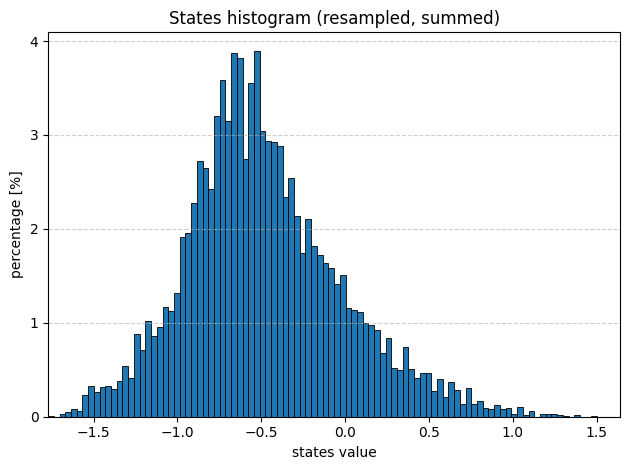

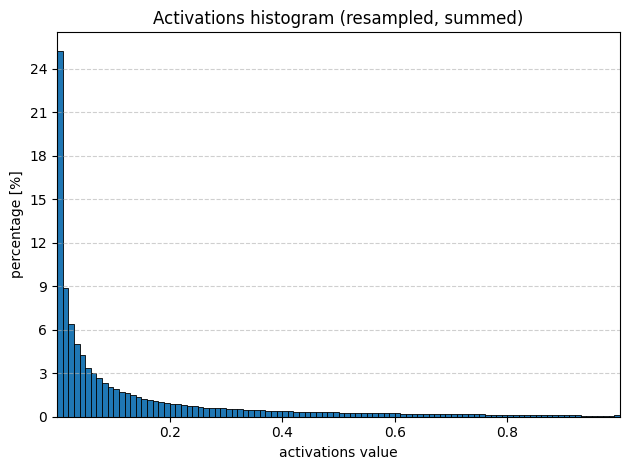

In [48]:
import json, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# load
# =========================
with open("/work/robomimic/quantize_logs/Weight/uunit128_8bit.json") as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

# =========================
# 共通ヒスト作成関数
# =========================
def plot_hist_resampled(data, key="states", n_bins=100, as_percent=False, title=None):
    mins, maxs = [], []
    for d in data:
        if key in d:
            mins.append(d[key]["min"])
            maxs.append(d[key]["max"])

    if not mins:
        raise ValueError(f"{key} not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    hist_sum = np.zeros(n_bins)

    for d in data:
        if key not in d:
            continue
        h = np.asarray(d[key]["hist"], dtype=float)
        step_min = d[key]["min"]
        step_max = d[key]["max"]

        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)

        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                if w > 0:
                    hist_sum[idx] += cnt / w  # density 換算
                else:
                    hist_sum[idx] += cnt

    if as_percent:
        hist_sum = hist_sum / hist_sum.sum() * 100.0

    centers = 0.5 * (edges_common[:-1] + edges_common[1:])
    widths = np.diff(edges_common)

    plt.bar(centers, hist_sum, width=widths, align="center",
            edgecolor="black", linewidth=0.6)
    plt.xlim(vmin, vmax)
    plt.xlabel(f"{key} value")
    plt.ylabel("percentage [%]" if as_percent else "density (summed)")
    if title:
        plt.title(title)

    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# =========================
# 可視化
# =========================
plot_hist_resampled(
    data,
    key="states",
    n_bins=100,
    as_percent=True,
    title="States histogram (resampled, summed)"
)

plot_hist_resampled(
    data,
    key="activations",
    n_bins=100,
    as_percent=True,
    title="Activations histogram (resampled, summed)"
)


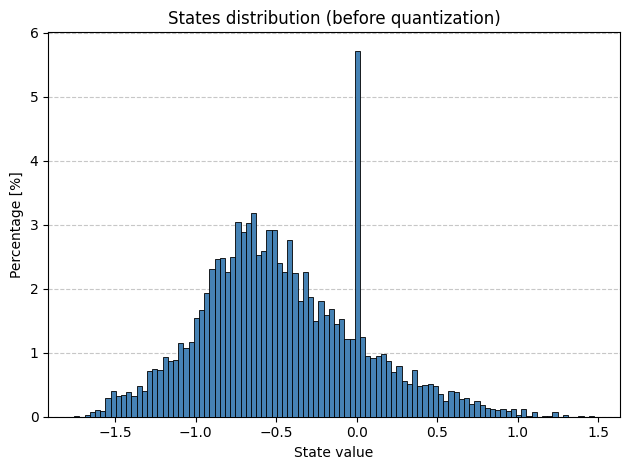

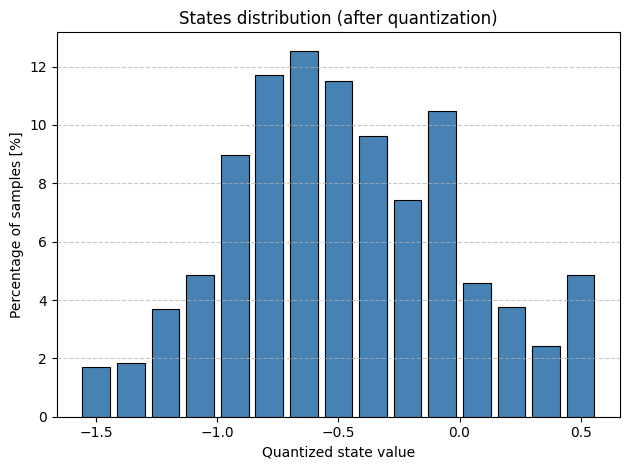

In [62]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from typing import Optional

# =========================
# Load JSON
# =========================
json_path = "/work/robomimic/quantize_logs/Weight/uunit128_8bit.json"
with open(json_path) as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

# =========================
# PTQ (mean-shift symmetric)
# =========================
@torch.no_grad()
def ptq_range(
    params: torch.Tensor,
    n_bits: int = 8,
    mean_val: float = -0.5,
    clip_val: Optional[float] = None,
):
    qmax = 2 ** (n_bits - 1) - 1
    x = params - mean_val

    if clip_val is not None:
        scale = clip_val / qmax
    else:
        scale = torch.max(torch.abs(x)) / qmax

    x_q = torch.round(x / scale).clamp(-qmax, qmax) * scale
    params.copy_((x_q + mean_val).to(params.dtype))
    return params

# =========================
# states をサンプルとして復元
# =========================
def collect_states_from_hist(data):
    values = []

    for d in data:
        if "states" not in d:
            continue

        st = d["states"]
        hist = np.asarray(st["hist"], dtype=int)
        vmin, vmax = st["min"], st["max"]

        edges = np.linspace(vmin, vmax, len(hist) + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        samples = np.repeat(centers, hist)
        if samples.size > 0:
            values.append(samples)

    if not values:
        raise ValueError("states not found")

    return np.concatenate(values)

# =========================
# before: 連続ヒストグラム
# =========================
def plot_states_hist_continuous(
    values,
    n_bins=100,
    title=None,
    value_range=None,   # 例: (-1.5, 0.5)
):
    if value_range is None:
        vmin, vmax = values.min(), values.max()
    else:
        vmin, vmax = value_range

    hist, edges = np.histogram(
        values,
        bins=n_bins,
        range=(vmin, vmax),
        density=True,     # ← 重要
    )

    # density → percentage
    bin_widths = np.diff(edges)
    hist_pct = hist * bin_widths * 100.0

    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.bar(
        centers,
        hist_pct,
        width=bin_widths,
        color="steelblue",
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xlabel("State value")
    plt.ylabel("Percentage [%]")
    if title:
        plt.title(title)

    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# =========================
# after: 離散分布（正解）
# =========================
def plot_discrete_quantized_states(
    values,
    as_percent=True,
    title=None,
):
    uniq, counts = np.unique(values, return_counts=True)

    if as_percent:
        counts = counts / counts.sum() * 100.0
        ylabel = "Percentage of samples [%]"
    else:
        ylabel = "Count"

    width = (uniq[1] - uniq[0]) * 0.8 if len(uniq) > 1 else 0.05

    plt.bar(
        uniq,
        counts,
        width=width,
        color="steelblue",
        edgecolor="black",
        linewidth=0.8,
    )

    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xlabel("Quantized state value")
    plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# =========================
# Main
# =========================
# collect continuous states
states = collect_states_from_hist(data)

# before quantization
plot_states_hist_continuous(
    states,
    n_bins=100,
    title="States distribution (before quantization)",
)

# quantize
states_q = torch.from_numpy(states).float()
ptq_range(
    states_q,
    n_bits=4,
    mean_val=-0.5,
    clip_val=1.0,
)
states_q = states_q.numpy()

# after quantization (DISCRETE)
plot_discrete_quantized_states(
    states_q,
    as_percent=True,
    title="States distribution (after quantization)",
)


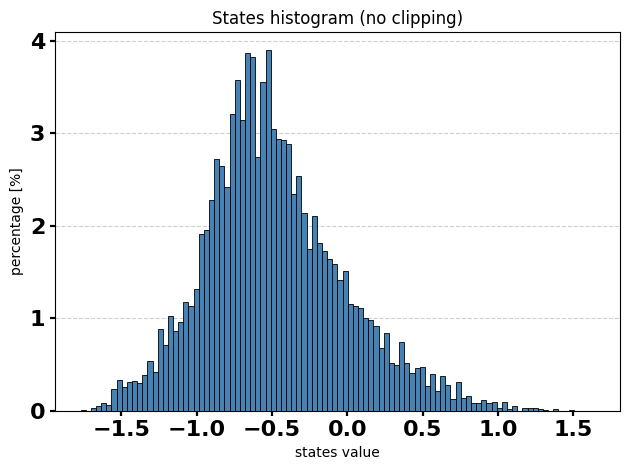

In [63]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

json_path = "/work/robomimic/quantize_logs/Weight/uunit128_8bit.json"
with open(json_path) as f:
    data_states = json.load(f)
if not data_states:
    raise ValueError("data is empty")

def plot_hist_states_no_clip(data, n_bins=100, as_percent=True, title=None):
    # 集約された共通ビンでリスケール
    mins, maxs = [], []
    for d in data:
        if "states" in d:
            mins.append(d["states"]["min"])
            maxs.append(d["states"]["max"])
    if not mins:
        raise ValueError("states not found")

    vmin, vmax = min(mins), max(maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    hist_sum = np.zeros(n_bins)

    for d in data:
        if "states" not in d:
            continue
        st = d["states"]
        h = np.asarray(st["hist"], dtype=float)
        step_min, step_max = st["min"], st["max"]
        edges_step = np.linspace(step_min, step_max, len(h) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        widths_step = np.diff(edges_step)
        for c, cnt, w in zip(centers_step, h, widths_step):
            idx = np.searchsorted(edges_common, c, side="right") - 1
            if 0 <= idx < n_bins:
                hist_sum[idx] += cnt if w <= 0 else cnt / w  # density 換算

    if as_percent and hist_sum.sum() > 0:
        hist_sum = hist_sum / hist_sum.sum() * 100.0

    centers = 0.5 * (edges_common[:-1] + edges_common[1:])
    widths = np.diff(edges_common)

    plt.bar(centers, hist_sum, width=widths, align="center",
            edgecolor="black", linewidth=0.6, color="steelblue", zorder=3)
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.tick_params(axis="both", labelsize=16, width=1.6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    plt.xlabel("states value")
    plt.ylabel("percentage [%]" if as_percent else "density (summed)")
    if title:
        plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 実行
plot_hist_states_no_clip(
    data_states,
    n_bins=100,
    as_percent=True,
    title="States histogram (no clipping)"
)

/tmp/ipykernel_2677705/1416631704.py:28: RuntimeWarning: divide by zero encountered in divide
  pdf = hist / widths
/tmp/ipykernel_2677705/1416631704.py:28: RuntimeWarning: invalid value encountered in divide
  pdf = hist / widths


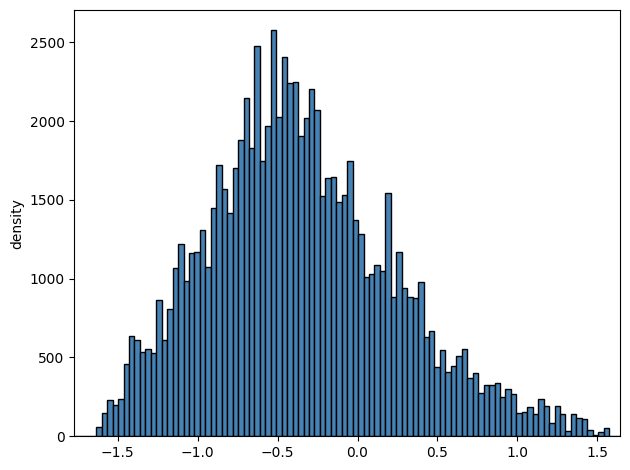

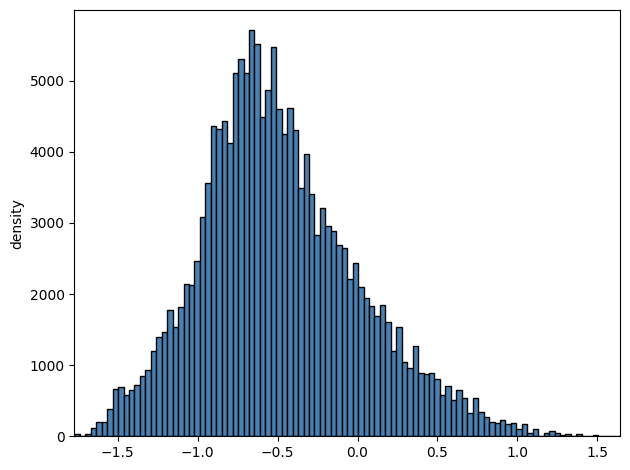

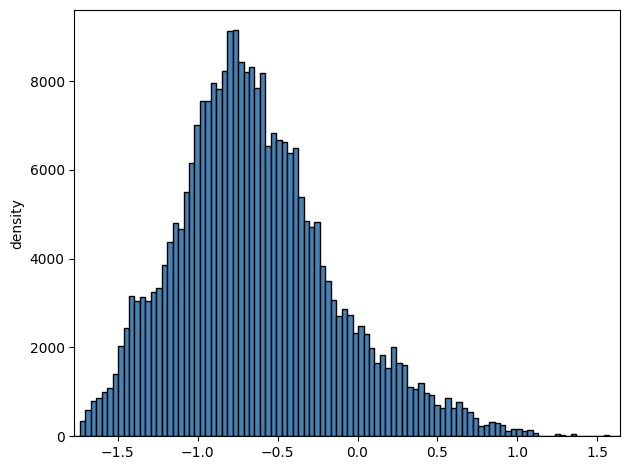

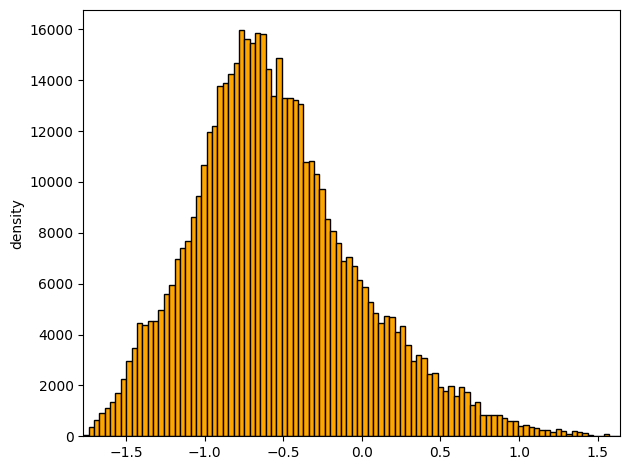

In [10]:
# ...existing code...

def plot_multi_states(json_paths, nbins=100, use_density=True):
    all_hists, all_edges = [], []
    for p in json_paths:
        h, e = load_states(p)
        all_hists.extend(h); all_edges.extend(e)
    if not all_hists:
        print("states hist is empty"); return

    vmin = min(e.min() for e in all_edges)
    vmax = max(e.max() for e in all_edges)
    common_edges = np.linspace(vmin, vmax, nbins + 1)
    widths = np.diff(common_edges)
    centers = 0.5 * (common_edges[:-1] + common_edges[1:])
    ylabel = "density" if use_density else "count"

    # ファイルごと
    for p in json_paths:
        h, e = load_states(p)
        if not h:
            continue
        reb = [rebin_hist(hi, ei, common_edges) for hi, ei in zip(h, e)]
        hist_sum = np.sum(reb, axis=0)
        y = hist_sum / widths if use_density else hist_sum
        plt.bar(
            centers, y, width=widths, align="center",
            edgecolor="black", linewidth=1.0,
            color="steelblue", alpha=1.0
        )
        plt.ylabel(ylabel)
        plt.xlim(vmin, vmax)
        plt.tight_layout()
        plt.show()

    # 全ファイル合算
    reb_all = [rebin_hist(h, e, common_edges) for h, e in zip(all_hists, all_edges)]
    hist_sum_all = np.sum(reb_all, axis=0)
    y_all = hist_sum_all / widths if use_density else hist_sum_all
    plt.bar(
        centers, y_all, width=widths, align="center",
        edgecolor="black", linewidth=1.0,
        color="orange", alpha=1.0
    )
    plt.ylabel(ylabel)
    plt.xlim(vmin, vmax)
    plt.tight_layout()
    plt.show()

# 例: density 表示（デフォルト）
plot_multi_states(json_paths, nbins=100, use_density=True)
# ...existing code...